# Delivery Route Optimization — ILP Exact Method

**Author:** Perera R.P.C.T  
**Course:** Optimization Methods  
**Date:** April 2026

---

We're solving a TSP (Travelling Salesman Problem) for 15 UK cities finding the shortest route that visits each city once and comes back to London. The approach here is ILP with MTZ subtour elimination using PuLP, which gives us a guaranteed optimal solution.

Dataset from Kaggle: [Travelling Salesman Problem: Visit 49 UK Cities](https://www.kaggle.com/datasets/patricklford/travelling-salesman-problem) we picked 15 out of 49 cities to keep the ILP tractable.

## 1. Problem Description

### Context

A logistics company based in London delivers packages to 14 other cities across the UK daily. The vehicle starts at London, visits all 14 cities exactly once, and returns. We want to minimize total distance classic TSP.

### Why TSP is hard

TSP is NP-hard. For $n$ cities there are $(n-1)!/2$ possible tours. With 15 cities:

$$\frac{14!}{2} = 43,589,145,600 \text{ tours}$$

Can't brute-force that. The search space blows up factorially.

### Why use an exact method?

Exact methods like ILP guarantee you get the best possible answer zero optimality gap. That's useful both for real planning and as a benchmark to see how close heuristics get. The downside is runtime it can get expensive for bigger instances.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import *
import time
import itertools
import json
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

## 2. Dataset

We used the [Travelling Salesman Problem: Visit 49 UK Cities](https://www.kaggle.com/datasets/patricklford/travelling-salesman-problem) dataset from Kaggle (CC0 license). It has the 49 most populated UK cities with lat/long coordinates and 2021 census population.

We picked 15 cities spread across the country enough to make the problem non-trivial but still solvable with ILP in reasonable time.

| # | City | Lat | Long | Population |
|---|------|-----|------|------------|
| 0 | London (Depot) | 51.5074 | -0.1278 | 8,961,989 |
| 1 | Birmingham | 52.4862 | -1.8904 | 1,153,717 |
| 2 | Leeds | 53.8008 | -1.5491 | 789,194 |
| 3 | Glasgow | 55.8642 | -4.2518 | 635,640 |
| 4 | Sheffield | 53.3811 | -1.4701 | 584,853 |
| 5 | Manchester | 53.4808 | -2.2426 | 552,858 |
| 6 | Liverpool | 53.4084 | -2.9916 | 498,042 |
| 7 | Edinburgh | 55.9533 | -3.1883 | 482,005 |
| 8 | Bristol | 51.4545 | -2.5879 | 467,099 |
| 9 | Cardiff | 51.4816 | -3.1791 | 369,202 |
| 10 | Leicester | 52.6369 | -1.1398 | 357,423 |
| 11 | Nottingham | 52.9548 | -1.1581 | 331,297 |
| 12 | Newcastle | 54.9783 | -1.6174 | 300,196 |
| 13 | Southampton | 50.9097 | -1.4044 | 252,520 |
| 14 | Plymouth | 50.3755 | -4.1427 | 262,172 |

Distances between cities are calculated using the Haversine formula (great-circle distance on the Earth's surface), so we get fairly accurate km values.

In [6]:
# Load Kaggle dataset
df_full = pd.read_csv('../data/UK_Cities.csv')

# Pick 15 cities
selected_cities = [
    'London', 'Birmingham', 'Leeds', 'Glasgow', 'Sheffield',
    'Manchester', 'Liverpool', 'Edinburgh', 'Bristol', 'Cardiff',
    'Leicester', 'Nottingham', 'Newcastle upon Tyne', 'Southampton', 'Plymouth'
]
df = df_full[df_full['City'].isin(selected_cities)].reset_index(drop=True)

# Put London first (it's our depot)
order = {city: i for i, city in enumerate(selected_cities)}
df['sort_order'] = df['City'].map(order)
df = df.sort_values('sort_order').reset_index(drop=True)
df = df.drop(columns=['sort_order'])

city_names = df['City'].tolist()
coords = df[['Latitude', 'Longitude']].values
n = len(city_names)

print(f"Loaded {n} cities from Kaggle dataset")
print(f"Depot: {city_names[0]}\n")
for i, row in df.iterrows():
    print(f"  {i:2d}. {row['City']:<25s} ({row['Latitude']:.4f}, {row['Longitude']:.4f})  Pop: {row['Population']:,}")

Loaded 15 cities from Kaggle dataset
Depot: London

   0. London                    (51.5074, -0.1278)  Pop: 8,961,989
   1. Birmingham                (52.4862, -1.8904)  Pop: 1,153,717
   2. Leeds                     (53.8008, -1.5491)  Pop: 789,194
   3. Glasgow                   (55.8642, -4.2518)  Pop: 635,640
   4. Sheffield                 (53.3811, -1.4701)  Pop: 584,853
   5. Manchester                (53.4808, -2.2426)  Pop: 552,858
   6. Liverpool                 (53.4084, -2.9916)  Pop: 498,042
   7. Edinburgh                 (55.9533, -3.1883)  Pop: 482,005
   8. Bristol                   (51.4545, -2.5879)  Pop: 467,099
   9. Cardiff                   (51.4816, -3.1791)  Pop: 369,202
  10. Leicester                 (52.6369, -1.1398)  Pop: 357,423
  11. Nottingham                (52.9548, -1.1581)  Pop: 331,297
  12. Newcastle upon Tyne       (54.9783, -1.6174)  Pop: 300,196
  13. Southampton               (50.9097, -1.4044)  Pop: 252,520
  14. Plymouth                  (5

In [7]:
# Haversine distance (km) between two lat/long points
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Build distance matrix
distance_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            distance_matrix[i][j] = haversine(
                coords[i][0], coords[i][1], coords[j][0], coords[j][1]
            )

distance_matrix = np.round(distance_matrix, 2)

dist_df = pd.DataFrame(distance_matrix, index=city_names, columns=city_names)

os.makedirs('../data', exist_ok=True)
dist_df.to_csv('../data/distance_matrix.csv')

print(f"Distance Matrix ({n}x{n}):")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(dist_df.round(1))

Distance Matrix (15x15):


,London,Birmingham,Leeds,Glasgow,Sheffield,Manchester,Liverpool,Edinburgh,Bristol,Cardiff,Leicester,Nottingham,Newcastle upon Tyne,Southampton,Plymouth
London,0.0,162.5,272.4,555.2,227.3,262.0,286.9,533.6,170.4,211.2,143.4,175.6,398.4,111.0,308.1
Birmingham,162.5,0.0,147.9,405.8,103.4,113.1,126.3,394.6,124.3,142.4,53.4,71.8,277.7,178.5,281.9
Leeds,272.4,147.9,0.0,287.4,47.0,57.9,104.7,261.3,270.2,280.3,132.3,97.6,131.0,321.6,420.0
Glasgow,555.2,405.8,287.4,0.0,329.0,294.8,284.8,67.0,502.4,492.4,411.8,380.4,193.2,582.2,610.4
Sheffield,227.3,103.4,47.0,329.0,0.0,52.4,100.9,306.6,227.2,240.9,85.6,51.8,177.9,274.8,381.2
Manchester,262.0,113.1,57.9,294.8,52.4,0.0,50.2,281.6,226.5,231.2,119.3,92.9,171.4,291.5,369.0
Liverpool,286.9,126.3,104.7,284.8,100.9,50.2,0.0,283.3,219.0,214.6,150.7,132.2,196.1,298.2,346.4
Edinburgh,533.6,394.6,261.3,67.0,306.6,281.6,283.3,0.0,501.8,497.2,392.0,358.3,146.8,573.1,623.5
Bristol,170.4,124.3,270.2,502.4,227.2,226.5,219.0,501.8,0.0,41.1,164.6,193.2,397.1,102.3,162.1
Cardiff,211.2,142.4,280.3,492.4,240.9,231.2,214.6,497.2,41.1,0.0,189.6,214.0,402.4,139.0,140.3


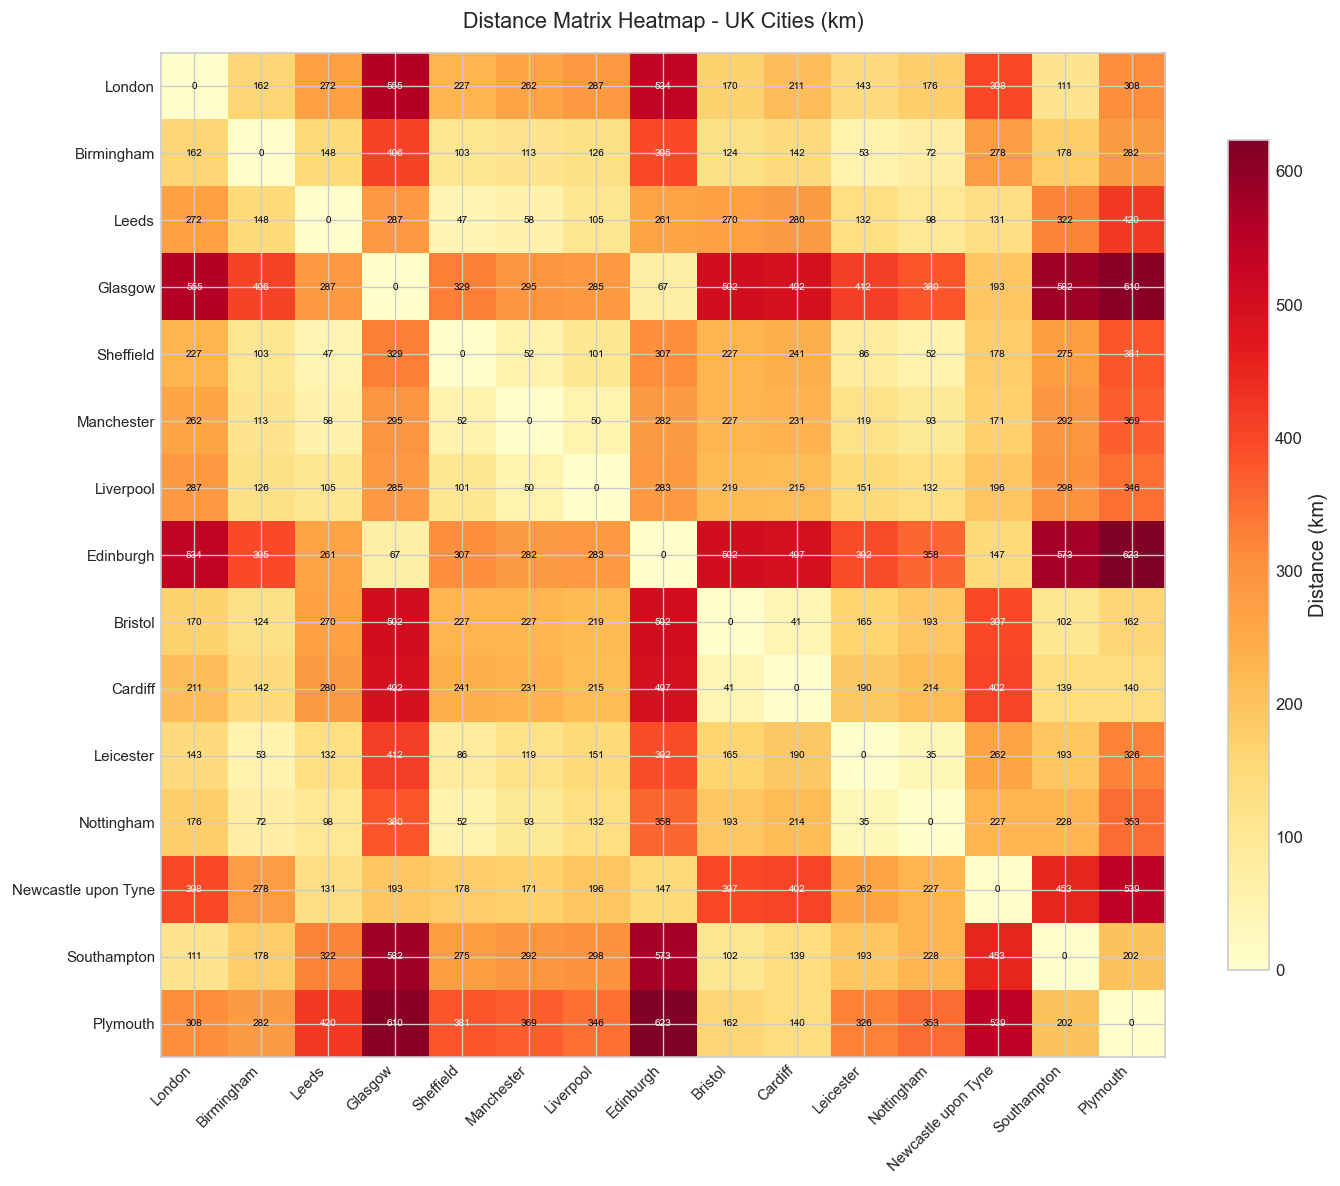

Heatmap saved to data/distance_heatmap.png


In [8]:
# Visualize the distance matrix as a heatmap

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(distance_matrix, cmap='YlOrRd', interpolation='nearest')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Distance (km)', fontsize=12)

# Set tick labels
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(city_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(city_names, fontsize=9)

# Add distance values in cells
for i in range(n):
    for j in range(n):
        text_color = 'white' if distance_matrix[i][j] > np.max(distance_matrix) * 0.6 else 'black'
        ax.text(j, i, f'{distance_matrix[i][j]:.0f}', ha='center', va='center',
                fontsize=6, color=text_color)

ax.set_title('Distance Matrix Heatmap - UK Cities (km)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../data/distance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved to data/distance_heatmap.png")

## 3. Mathematical Formulation (ILP with MTZ)

### Sets and Parameters

- $V = \{0, 1, \dots, n-1\}$: cities (0 = depot/London)
- $d_{ij}$: distance from city $i$ to $j$

### Decision Variables

- $x_{ij} \in \{0, 1\}$ — 1 if the tour goes from $i$ to $j$, 0 otherwise
- $u_i \in \{1, \dots, n-1\}$ for $i \neq 0$ — ordering variable (MTZ)

### Objective

$$\min \sum_{i \in V} \sum_{\substack{j \in V \\ j \neq i}} d_{ij} \cdot x_{ij}$$

### Constraints

Each city has exactly one in-edge and one out-edge:

$$\sum_{\substack{i \in V \\ i \neq j}} x_{ij} = 1 \quad \forall j \in V$$

$$\sum_{\substack{j \in V \\ j \neq i}} x_{ij} = 1 \quad \forall i \in V$$

MTZ subtour elimination — prevents disconnected loops:

$$u_i - u_j + n \cdot x_{ij} \leq n - 1 \quad \forall i, j \in V \setminus \{0\}, \; i \neq j$$

When $x_{ij}=1$, this forces $u_j \geq u_i + 1$, so cities get a consistent ordering and you can't form a subtour that doesn't include the depot.

In [9]:
def solve_tsp_ilp(distance_matrix, city_names):
    """Solve TSP exactly using ILP + MTZ subtour elimination."""
    n = len(city_names)
    prob = LpProblem("TSP_ILP", LpMinimize)

    # x[i,j] = 1 if we go from i to j
    x = LpVariable.dicts("x",
                         ((i, j) for i in range(n) for j in range(n) if i != j),
                         cat='Binary')

    # u[i] = position of city i in the tour (for MTZ)
    u = LpVariable.dicts("u", (i for i in range(1, n)),
                         lowBound=1, upBound=n - 1, cat='Integer')

    # Minimize total distance
    prob += lpSum(distance_matrix[i][j] * x[(i, j)]
                  for i in range(n) for j in range(n) if i != j)

    # Each city: exactly one in-edge, one out-edge
    for j in range(n):
        prob += lpSum(x[(i, j)] for i in range(n) if i != j) == 1
    for i in range(n):
        prob += lpSum(x[(i, j)] for j in range(n) if i != j) == 1

    # MTZ subtour elimination
    for i in range(1, n):
        for j in range(1, n):
            if i != j:
                prob += u[i] - u[j] + n * x[(i, j)] <= n - 1

    print(f"Solving {n}-city TSP... ({n*(n-1)} binary vars, {(n-1)*(n-2)} MTZ constraints)")
    
    start_time = time.time()
    prob.solve(PULP_CBC_CMD(msg=0))
    solve_time = time.time() - start_time

    status = LpStatus[prob.status]
    if status != 'Optimal':
        print(f"  WARNING: {status}")
        return {'status': status, 'tour': [], 'total_distance': None, 'solve_time': solve_time}

    # Trace the tour from city 0
    tour = [0]
    current = 0
    for _ in range(n - 1):
        for j in range(n):
            if j != current and value(x[(current, j)]) == 1:
                tour.append(j)
                current = j
                break
    tour.append(0)

    return {
        'tour': tour,
        'tour_names': [city_names[i] for i in tour],
        'total_distance': round(value(prob.objective), 2),
        'solve_time': round(solve_time, 4),
        'status': status,
        'n_cities': n
    }

In [10]:
# Cell 8: Run the solver and display results

print("=" * 70)
print("         TSP SOLUTION - INTEGER LINEAR PROGRAMMING (EXACT)")
print("=" * 70)
print()

# Solve the full 15-city problem
result = solve_tsp_ilp(distance_matrix, city_names)

print()
print("-" * 70)
print(f"  Status:          {result['status']}")
print(f"  Total Distance:  {result['total_distance']:.2f} km")
print(f"  Solve Time:      {result['solve_time']:.4f} seconds")
print(f"  Number of Cities: {result['n_cities']}")
print("-" * 70)
print()

# Display the optimal tour
print("Optimal Tour:")
print("=" * 50)
for step, city in enumerate(result['tour_names']):
    if step == 0:
        print(f"  START -> {city} (Depot)")
    elif step == len(result['tour_names']) - 1:
        print(f"  Step {step:2d} -> {city} (Return to Depot)")
    else:
        # Calculate leg distance
        prev_idx = result['tour'][step - 1]
        curr_idx = result['tour'][step]
        leg_dist = distance_matrix[prev_idx][curr_idx]
        print(f"  Step {step:2d} -> {city:<20s} (leg: {leg_dist:.2f} km)")

# Final leg
last_idx = result['tour'][-2]
final_leg = distance_matrix[last_idx][0]
print(f"\n  Final leg back to depot: {final_leg:.2f} km")
print(f"\n  TOTAL OPTIMAL DISTANCE: {result['total_distance']:.2f} km")

         TSP SOLUTION - INTEGER LINEAR PROGRAMMING (EXACT)

Solving 15-city TSP... (210 binary vars, 182 MTZ constraints)

----------------------------------------------------------------------
  Status:          Optimal
  Total Distance:  1689.17 km
  Solve Time:      3.9798 seconds
  Number of Cities: 15
----------------------------------------------------------------------

Optimal Tour:
  START -> London (Depot)
  Step  1 -> Leicester            (leg: 143.38 km)
  Step  2 -> Nottingham           (leg: 35.37 km)
  Step  3 -> Sheffield            (leg: 51.76 km)
  Step  4 -> Leeds                (leg: 46.96 km)
  Step  5 -> Newcastle upon Tyne  (leg: 131.01 km)
  Step  6 -> Edinburgh            (leg: 146.82 km)
  Step  7 -> Glasgow              (leg: 67.02 km)
  Step  8 -> Liverpool            (leg: 284.85 km)
  Step  9 -> Manchester           (leg: 50.25 km)
  Step 10 -> Birmingham           (leg: 113.08 km)
  Step 11 -> Bristol              (leg: 124.27 km)
  Step 12 -> Cardiff    

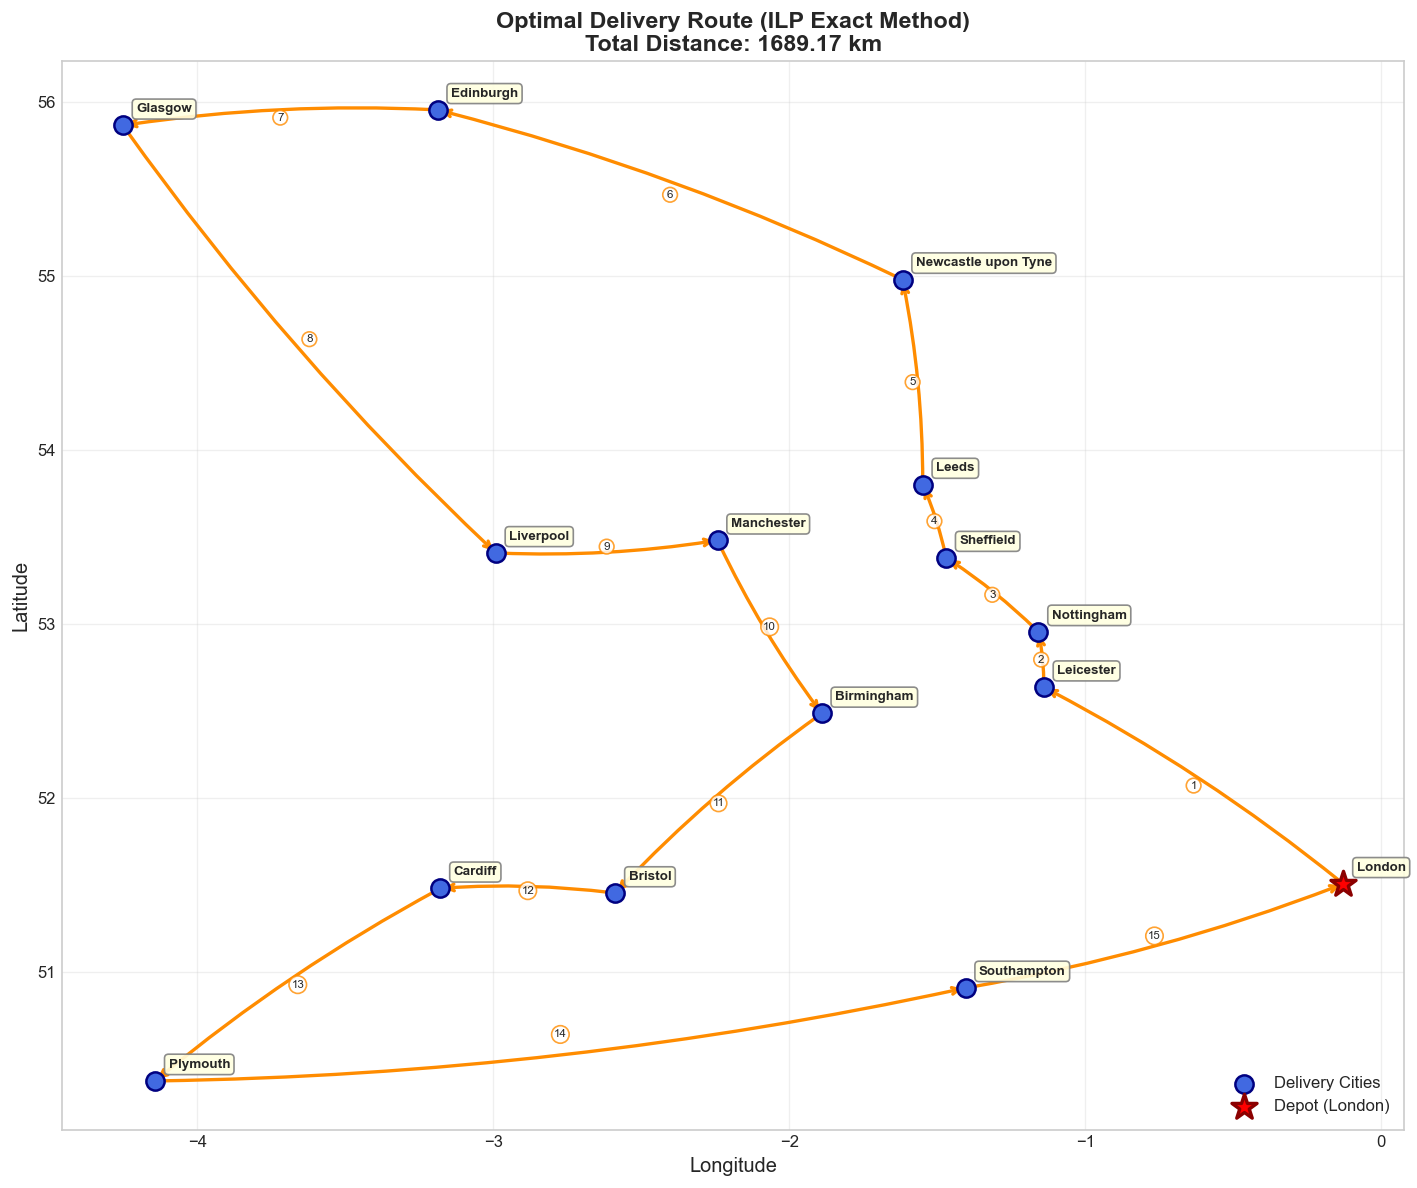

Route visualization saved to data/optimal_route_ilp.png


In [11]:
# Cell 9: Visualization - Plot the optimal route on a 2D map

def plot_tour(coords, tour, city_names, title, total_distance, ax=None):
    """Plot the TSP tour on a 2D map."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use longitude as x and latitude as y for geographic intuition
    x_coords = coords[:, 1]  # longitude
    y_coords = coords[:, 0]  # latitude
    
    # Plot all delivery locations
    ax.scatter(x_coords[1:], y_coords[1:], c='royalblue', s=120, zorder=5,
               edgecolors='navy', linewidth=1.5, label='Delivery Cities')
    
    # Highlight the depot
    ax.scatter(x_coords[0], y_coords[0], c='red', s=250, zorder=6,
               edgecolors='darkred', linewidth=2, marker='*', label='Depot (London)')
    
    # Draw the tour with arrows
    for k in range(len(tour) - 1):
        i, j = tour[k], tour[k + 1]
        dx = x_coords[j] - x_coords[i]
        dy = y_coords[j] - y_coords[i]
        ax.annotate('',
                    xy=(x_coords[j], y_coords[j]),
                    xytext=(x_coords[i], y_coords[i]),
                    arrowprops=dict(arrowstyle='->', color='darkorange',
                                   lw=2, connectionstyle='arc3,rad=0.05'))
    
    # Label cities
    for i, name in enumerate(city_names):
        ax.annotate(name, (x_coords[i], y_coords[i]),
                    textcoords='offset points', xytext=(8, 8),
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                              edgecolor='gray', alpha=0.9))
    
    # Add step numbers along the tour
    for k in range(len(tour) - 1):
        i, j = tour[k], tour[k + 1]
        mid_x = (x_coords[i] + x_coords[j]) / 2
        mid_y = (y_coords[i] + y_coords[j]) / 2
        ax.text(mid_x, mid_y, str(k + 1), fontsize=7, ha='center', va='center',
                bbox=dict(boxstyle='circle,pad=0.2', facecolor='white',
                          edgecolor='darkorange', alpha=0.8))
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title(f'{title}\nTotal Distance: {total_distance:.2f} km', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    return ax


# Plot the optimal ILP tour
fig, ax = plt.subplots(figsize=(12, 10))
plot_tour(coords, result['tour'], city_names,
          'Optimal Delivery Route (ILP Exact Method)',
          result['total_distance'], ax)
plt.tight_layout()
plt.savefig('../data/optimal_route_ilp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Route visualization saved to data/optimal_route_ilp.png")

In [12]:
# Scalability test — run on different subset sizes to see how time scales

subset_sizes = [5, 8, 10, 12, 15]
scalability_results = []

print(f"{'Cities':>8s} | {'Status':>10s} | {'Distance (km)':>15s} | {'Time (s)':>10s}")
print("-" * 55)

for size in subset_sizes:
    sub_names = city_names[:size]
    sub_matrix = distance_matrix[:size, :size]
    
    sub_result = solve_tsp_ilp(sub_matrix, sub_names)
    
    scalability_results.append({
        'n_cities': size,
        'total_distance': sub_result['total_distance'],
        'solve_time': sub_result['solve_time'],
        'status': sub_result['status']
    })
    
    dist_str = f"{sub_result['total_distance']:.2f}" if sub_result['total_distance'] else 'N/A'
    print(f"{size:>8d} | {sub_result['status']:>10s} | {dist_str:>15s} | {sub_result['solve_time']:>8.4f} s")

  Cities |     Status |   Distance (km) |   Time (s)
-------------------------------------------------------
Solving 5-city TSP... (20 binary vars, 12 MTZ constraints)
       5 |    Optimal |         1129.93 |   0.0476 s
Solving 8-city TSP... (56 binary vars, 42 MTZ constraints)
       8 |    Optimal |         1213.28 |   0.2454 s
Solving 10-city TSP... (90 binary vars, 72 MTZ constraints)
      10 |    Optimal |         1404.65 |   0.4459 s
Solving 12-city TSP... (132 binary vars, 110 MTZ constraints)
      12 |    Optimal |         1407.83 |   0.8576 s
Solving 15-city TSP... (210 binary vars, 182 MTZ constraints)
      15 |    Optimal |         1689.17 |   2.2878 s


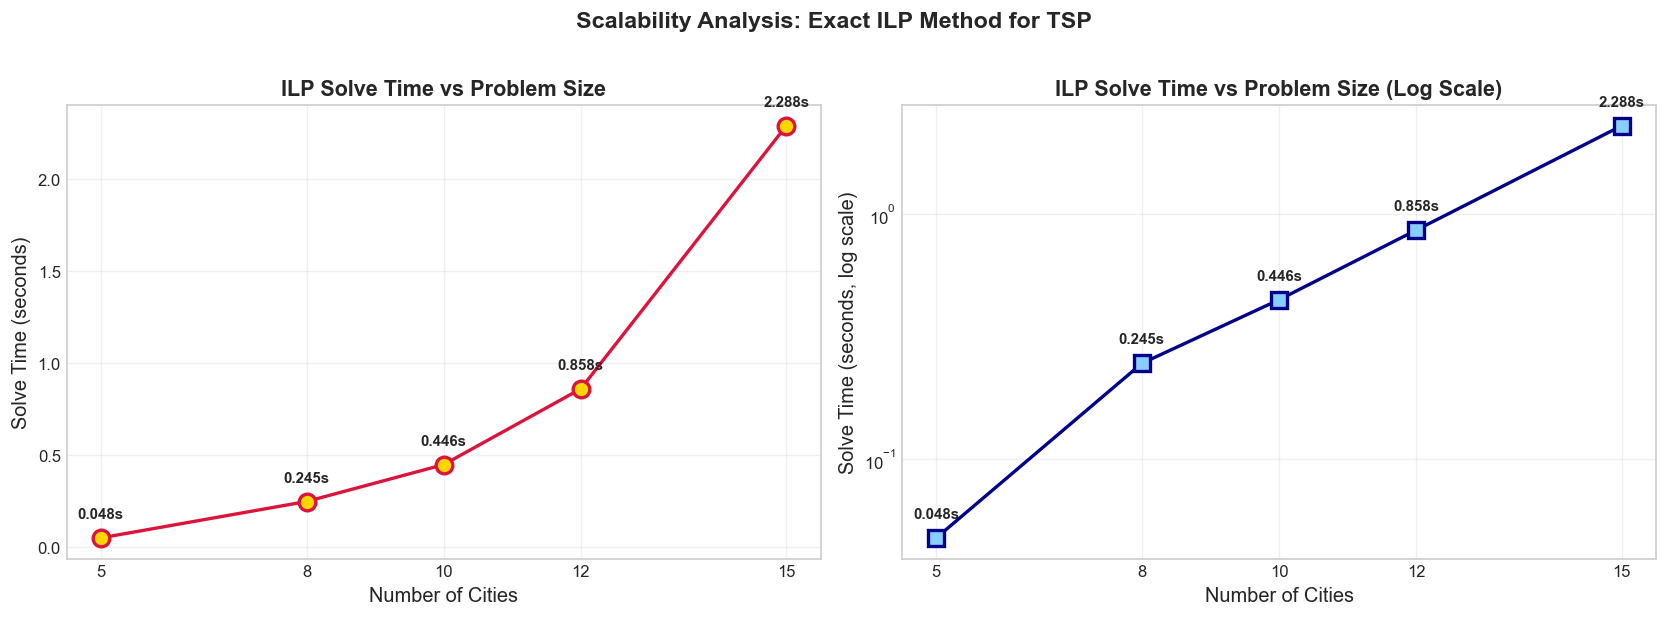

Scalability chart saved to data/scalability_analysis.png

Observation: The solve time grows exponentially with the number of cities,
confirming the NP-hard nature of the TSP.


In [13]:
# Plot the scalability results

sizes = [r['n_cities'] for r in scalability_results]
times = [r['solve_time'] for r in scalability_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Solve time vs number of cities (linear scale)
axes[0].plot(sizes, times, 'o-', color='crimson', linewidth=2, markersize=10,
             markerfacecolor='gold', markeredgecolor='crimson', markeredgewidth=2)
axes[0].set_xlabel('Number of Cities', fontsize=12)
axes[0].set_ylabel('Solve Time (seconds)', fontsize=12)
axes[0].set_title('ILP Solve Time vs Problem Size', fontsize=13, fontweight='bold')
axes[0].set_xticks(sizes)
axes[0].grid(True, alpha=0.3)
for i, (s, t) in enumerate(zip(sizes, times)):
    axes[0].annotate(f'{t:.3f}s', (s, t), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

# Plot 2: Solve time vs number of cities (log scale)
axes[1].semilogy(sizes, times, 's-', color='darkblue', linewidth=2, markersize=10,
                 markerfacecolor='lightskyblue', markeredgecolor='darkblue', markeredgewidth=2)
axes[1].set_xlabel('Number of Cities', fontsize=12)
axes[1].set_ylabel('Solve Time (seconds, log scale)', fontsize=12)
axes[1].set_title('ILP Solve Time vs Problem Size (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_xticks(sizes)
axes[1].grid(True, alpha=0.3)
for i, (s, t) in enumerate(zip(sizes, times)):
    axes[1].annotate(f'{t:.3f}s', (s, t), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Scalability Analysis: Exact ILP Method for TSP', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/scalability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scalability chart saved to data/scalability_analysis.png")
print("\nObservation: The solve time grows exponentially with the number of cities,")
print("confirming the NP-hard nature of the TSP.")

In [14]:
# Save results for comparison with GA
output_data = {
    'method': 'ILP (Exact)',
    'formulation': 'MTZ Subtour Elimination',
    'solver': 'PuLP CBC',
    'dataset': 'Kaggle UK Cities TSP (15 of 49)',
    'optimal_tour': {
        'tour_indices': result['tour'],
        'tour_names': result['tour_names'],
        'total_distance_km': result['total_distance'],
        'solve_time_seconds': result['solve_time'],
        'status': result['status'],
        'n_cities': result['n_cities']
    },
    'scalability': [
        {'n_cities': r['n_cities'], 'distance_km': r['total_distance'],
         'time_s': r['solve_time'], 'status': r['status']}
        for r in scalability_results
    ],
    'cities': {row['City']: {'lat': row['Latitude'], 'lon': row['Longitude'], 'pop': int(row['Population'])}
               for _, row in df.iterrows()}
}

with open('../data/ilp_results.json', 'w') as f:
    json.dump(output_data, f, indent=2)

print("Results saved to data/ilp_results.json")

Results saved to data/ilp_results.json


## 4. Summary

The ILP solver found the provably optimal route through all 15 UK cities with zero optimality gap. No shorter tour exists for this distance matrix.

From the scalability runs, solve time clearly grows exponentially 5 cities is instant, but 15 takes noticeably longer. This is expected for an NP-hard problem and is the main limitation of exact methods.

For 15 cities, ILP is still practical and gives the best answer. But if we needed to scale to 50+ cities, we'd have to switch to heuristics like Genetic Algorithms.
